In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math as mt
from scipy.stats import norm
from scipy.stats import truncnorm

In [2]:
np.random.seed(123)

### Homoscedastic errors

$$\hat \mu = \frac{1}{N}\sum_{i=1}^N x_i$$ mean estimator for a gaussian distributed sample with homoscedastic uncertainties.

$$\sigma_{\mu} = \frac{\sigma}{\sqrt{N}}$$ error on the mean estimator for a gaussian distributed sample with homoscedastic uncertainties.

So, our estimator of $\mu$ is $\overline{x}\pm\frac{\sigma}{\sqrt{N}}$, which is a result that you should be familiar with.

In [3]:
mu, sigma, N = 1, 0.2, 5 # mean, standard deviation and number of measurements
sample = np.random.normal(mu, sigma, N)
grid = np.linspace(0, 2, 1000)

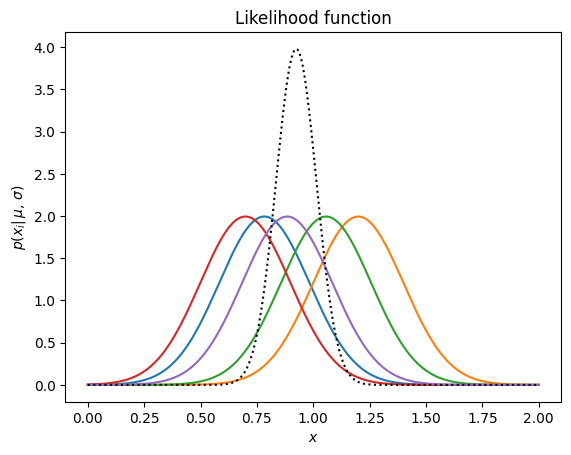

In [4]:
L = np.ones(len(grid))
for i in range(N):
    plt.plot(grid, norm.pdf(grid, sample[i], sigma))
    L = L*norm.pdf(grid, sample[i], sigma)
plt.plot(grid, L, c="black", ls='dotted')
plt.title("Likelihood function")
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x_i|\, \mu,\, \sigma)$')
plt.show()

In [5]:
# mu that maximizes L
findmax = grid[np.argmax(L)]

print(f"true mean ={mu: .2f}")
print(f"mean estimator ={findmax: .4f}")
print(f"sample arithmetic mean ={np.mean(sample): .4f}")

true mean = 1.00
mean estimator = 0.9249
sample arithmetic mean = 0.9244


In [6]:
mu, sigma, N = 1, 0.2, 5000 # mean, standard deviation and number of measurements
sample = np.random.normal(mu, sigma, N)
grid = np.linspace(0, 2, 1000)

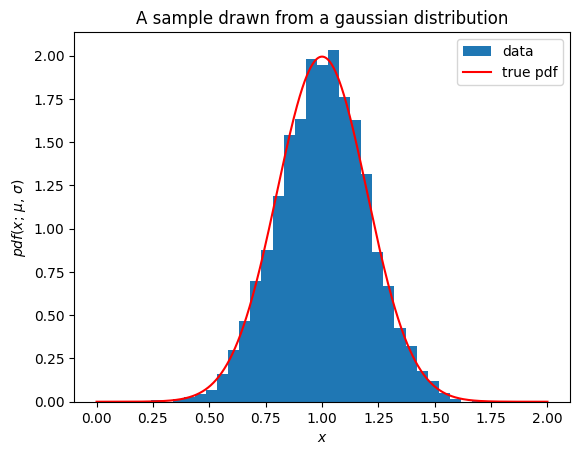

In [7]:
plt.hist(sample, bins=30, density=True, label="data")
plt.plot(grid, norm.pdf(grid, mu, sigma), '-r', label="true pdf")
plt.xlabel(r'$x$')
plt.ylabel(r'$pdf(x;\, \mu,\, \sigma)$')
plt.title("A sample drawn from a gaussian distribution")
plt.legend()
plt.show()

In [8]:
mu_proposed = np.linspace(0.5, 1.5, 1000)

In [9]:
# compute the lnL for each possible mu
lnL_scan = []
for mu_i in mu_proposed:
    lnL_temp = norm.logpdf(sample, mu_i, sigma) # gives you the log prob. density
    lnL_temp = np.sum(lnL_temp) # sum over the log pdf of all data points
    lnL_scan.append(lnL_temp)

In [10]:
# convert to numpy array
lnL_scan = np.array(lnL_scan)

# mu_proposed that maximizes the lnL
findmax = mu_proposed[np.argmax(lnL_scan)]

print(f"true mean ={mu: .2f}")
print(f"mean estimator ={findmax: .4f}")
print(f"sample arithmetic mean ={np.mean(sample): .4f}")

true mean = 1.00
mean estimator = 1.0045
sample arithmetic mean = 1.0043


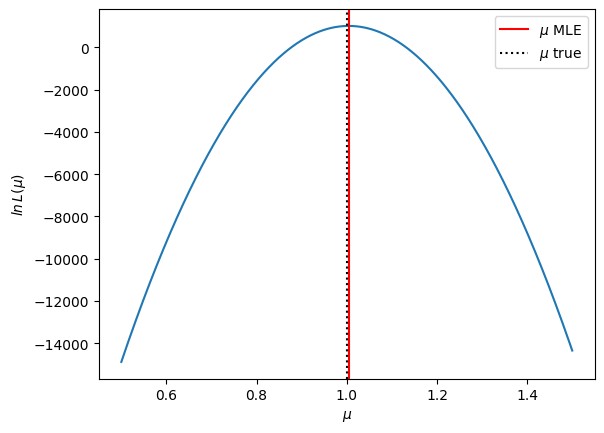

In [11]:
plt.plot(mu_proposed, lnL_scan)
plt.axvline(findmax, c='red', label=r"$\mu$ MLE")
plt.axvline(mu, c='black', ls='dotted', label=r"$\mu$ true")
plt.xlabel(r'$\mu$')
plt.ylabel(r'$ln\,L(\mu)$')
plt.legend()
plt.show()

In [12]:
# let's compute the Fisher information matrix in 1D to obtain the MLE uncertainty
diff2_lnL = np.diff(lnL_scan, 2)
d2_lnL = diff2_lnL/(0.001*np.ones(len(diff2_lnL)))**2
vec_mu_error = 1/np.sqrt(-1*d2_lnL)
mu_error = vec_mu_error[np.argmax(lnL_scan)]

In [13]:
print(f"error on the mean estimator ={mu_error: .4f}")
print(f"error on the sample arithmetic mean ={sigma/np.sqrt(N): .4f}")

error on the mean estimator = 0.0028
error on the sample arithmetic mean = 0.0028


### Heteroscedastic errors

$$\hat \mu = \frac{\sum_i^N (x_i/\sigma_i^2)}{\sum_i^N (1/\sigma_i^2)}$$ mean estimator for a gaussian distributed sample with heteroscedastic uncertainties.

$$\sigma_{\mu} = \left( \sum_{i=1}^N \frac{1}{\sigma_i^2}\right)^{-1/2}$$ error on the mean estimator for a gaussian distributed sample with heteroscedastic uncertainties.

In [14]:
N = 5 # number of measurements
s_mu, s_sigma = 0.2, 0.05 # mean and standard deviation of measurement errors
# Use a truncated normal distribution to ensure sigma_sample values are non-negative
sigma_sample = truncnorm.rvs((0 - s_mu) / s_sigma, np.inf, loc=s_mu, scale=s_sigma, size=N)

pos_sample = []
for sigma_i in sigma_sample:
    pos_sample.append(np.random.normal(mu, sigma_i))
pos_sample = np.array(pos_sample)

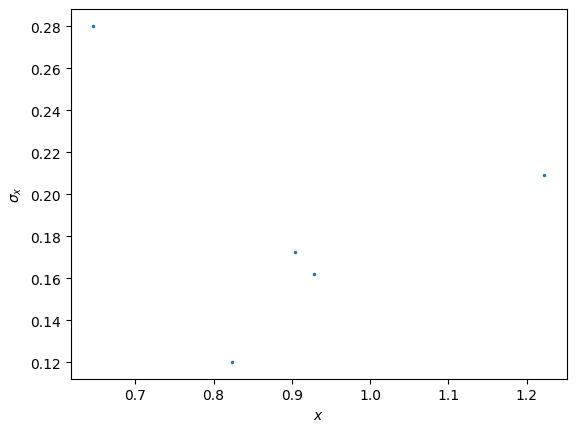

In [15]:
plt.plot(pos_sample, sigma_sample, markersize=3, marker='.', linestyle="")
plt.xlabel(r'$x$')
plt.ylabel(r'$\sigma_x$')
plt.show()

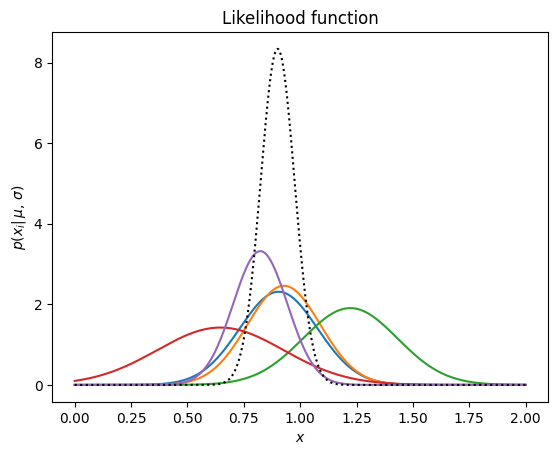

In [16]:
L = np.ones(len(grid))
for i in range(N):
    plt.plot(grid, norm.pdf(grid, pos_sample[i], sigma_sample[i]))
    L = L*norm.pdf(grid, pos_sample[i], sigma_sample[i])
plt.plot(grid, L, c="black", ls='dotted')
plt.title("Likelihood function")
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x_i|\, \mu,\, \sigma)$')
plt.show()

In [17]:
# mu that maximizes L
findmax = grid[np.argmax(L)]

# definition of the weights
pesi = 1/sigma_sample**2
valori = pos_sample

print(f"true mean ={mu: .2f}")
print(f"mean estimator ={findmax: .4f}")
print(f"sample mean ={np.average(valori, weights=pesi): .4f}")

true mean = 1.00
mean estimator = 0.9009
sample mean = 0.9001


In [18]:
N = 500 # number of measurements
s_mu, s_sigma = 0.2, 0.05 # mean and standard deviation of measurement errors
# Use a truncated normal distribution to ensure sigma_sample values are non-negative
sigma_sample = truncnorm.rvs((0 - s_mu) / s_sigma, np.inf, loc=s_mu, scale=s_sigma, size=N)

pos_sample = []
for sigma_i in sigma_sample:
    pos_sample.append(np.random.normal(mu, sigma_i))
pos_sample = np.array(pos_sample)

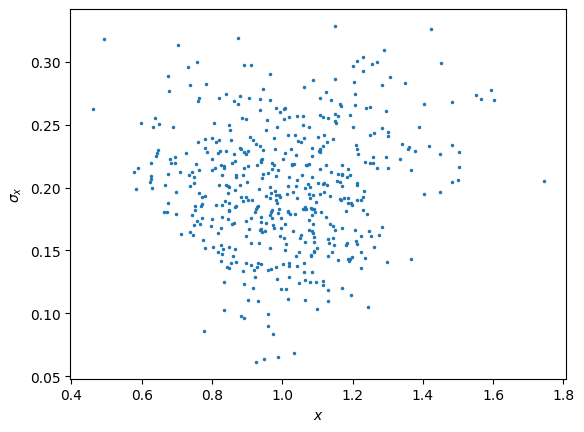

In [19]:
plt.plot(pos_sample, sigma_sample, markersize=3, marker='.', linestyle="")
plt.xlabel(r'$x$')
plt.ylabel(r'$\sigma_x$')
plt.show()

In [20]:
lnL_scan = []
for mu_i in mu_proposed:
  lnL_temp = []
  for i in range(len(sigma_sample)):
    lnL_temp.append(norm.logpdf(pos_sample[i], mu_i, sigma_sample[i])) # gives you the log prob. density
  lnL_temp = np.array(lnL_temp)
  lnL_scan.append(np.sum(lnL_temp)) # sum over the log pdf of all data points

In [21]:
# convert to numpy array
lnL_scan = np.array(lnL_scan)

# mu_proposed that maximizes the lnL
findmax = mu_proposed[np.argmax(lnL_scan)]

# definition of the weights
pesi = 1/sigma_sample**2
valori = pos_sample

print(f"true mean ={mu: .2f}")
print(f"mean estimator ={findmax: .4f}")
print(f"sample mean ={np.average(valori, weights=pesi): .4f}")

true mean = 1.00
mean estimator = 1.0015
sample mean = 1.0012


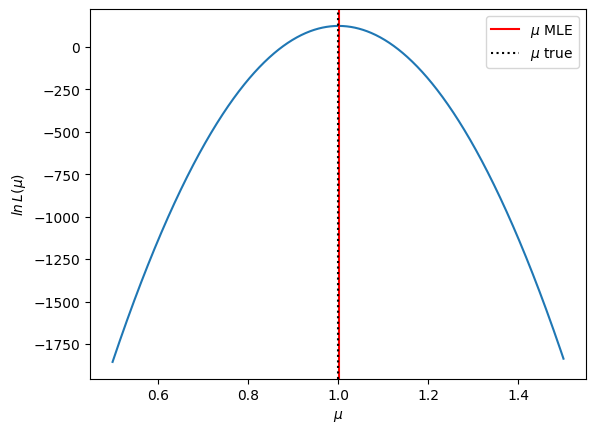

In [22]:
plt.plot(mu_proposed, lnL_scan)
plt.axvline(findmax, c='red', label=r"$\mu$ MLE")
plt.axvline(1, c='black', ls='dotted', label=r"$\mu$ true")
plt.xlabel(r'$\mu$')
plt.ylabel(r'$ln\,L(\mu)$')
plt.legend()
plt.show()

In [23]:
# let's compute the Fisher information matrix in 1D to obtain the MLE uncertainty
diff2_lnL = np.diff(lnL_scan, 2)
d2_lnL = diff2_lnL/(0.001*np.ones(len(diff2_lnL)))**2
vec_mu_error = 1/np.sqrt(-1*d2_lnL)
mu_error = vec_mu_error[np.argmax(lnL_scan)]

In [24]:
print(f"error on the mean estimator ={mu_error: .4f}")
print(f"error on the sample mean ={np.sum(pesi)**-0.5: .4f}")

error on the mean estimator = 0.0080
error on the sample mean = 0.0080
